In [1]:
import pandas as pd
import numpy as np

# Read climate and financial data
df = pd.read_csv("../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv", index_col=0)
df = df.rename(columns={"index_nsa": "hpi"})

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_90225/3422223062.py:5: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv", index_col=0)


### Prepare the data

In [2]:
# Subset for data in California from 2018-2020
df_ca_2018_2020 = df[
    (df['yr'].between(2018, 2020)) & (df['state'] == 'CALIFORNIA') ]

In [3]:
# Read data from California wildfire insurance
wildfire_insurance = pd.read_excel("../../02_processed_data/Residential-Property-Coverage-Amounts-Wildfire-Risk-and-Losses_Export.xlsx", 
sheet_name="Export_all", header=2)

In [4]:
# Subset data from 2018-2020, with homeowner premium insurance type
wildfire_insurance['Calendar Year'] += 2000
wildfire_insurance_18_20 = wildfire_insurance[
    (wildfire_insurance['Policy Type'] == "HO") & (wildfire_insurance['Calendar Year'].between(2018, 2020))]

# Keep the column of interest
wildfire_insurance_18_20 = wildfire_insurance_18_20[["Calendar Year", "ZIP Code", "Earned Prem", "Earned Exp"]]

In [5]:
# Load crosswalk file
crosswalk = pd.read_excel("../../01_original_data/ZIP_COUNTY_122020.xlsx", dtype={'ZIP': str, 'COUNTY': str})

# Keep only the data from California
crosswalk_ca = crosswalk[crosswalk['ZIP'].str.startswith('9')]

In [6]:
# Force the zipcode to be a string
wildfire_insurance_18_20['ZIP Code'] = wildfire_insurance_18_20['ZIP Code'].astype(str)

# Keep only the largest res_ratio county for each zipcode to avoid 1 to many merge issue
crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)
crosswalk_ca_sorted = crosswalk_ca.sort_values(by=['ZIP', 'RES_RATIO'], ascending=[True, False])
crosswalk_main = crosswalk_ca_sorted.drop_duplicates(subset=['ZIP'], keep='first')

# Merge the wildfire_insurance file with the crosswalk
wildfire_zip = wildfire_insurance_18_20.merge(
    crosswalk_main[['ZIP', 'COUNTY']], 
    left_on='ZIP Code', right_on='ZIP', 
    how='left'
)

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_90225/3822516419.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)


In [7]:
# Add the 0 to county fips code 
df_ca_2018_2020["county_fips5"] = df_ca_2018_2020["county_fips5"].astype(str).str.zfill(5)

wildfire_zip = wildfire_zip.rename(columns={"COUNTY": "county_fips5", "Calendar Year": "yr"})

# Merge and get the final dataframe
final_df = wildfire_zip.merge(
    df_ca_2018_2020,
    on=['county_fips5', 'yr'],
    how='left'
)

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_90225/3499580463.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ca_2018_2020["county_fips5"] = df_ca_2018_2020["county_fips5"].astype(str).str.zfill(5)


In [8]:
final_df = final_df.drop(columns=["ZIP"])

# Create premium per unit to show average earned premium for each housing unit
final_df = final_df[final_df['Earned Exp'] > 0]
final_df['prem_per_unit'] = final_df['Earned Prem'] / final_df['Earned Exp']

In [9]:
final_df['total_amt_purchase'] = pd.to_numeric(final_df['total_amt_purchase'], errors='coerce')
final_df['total_home_purchase'] = pd.to_numeric(final_df['total_home_purchase'], errors='coerce')

final_df['real_gdp'] = pd.to_numeric(final_df['real_gdp'], errors='coerce')
final_df['total_population'] = pd.to_numeric(final_df['total_population'], errors='coerce')

In [10]:
# Create average home mortgage amount per housing unit
final_df['mortgage_per_unit'] = final_df['total_amt_purchase'] / final_df['total_home_purchase']

# Create real gdp per capita
final_df['gdp_per_capita'] = final_df['real_gdp'] / final_df['total_population']

# Create debt to income ratio
final_df['debt_income_ratio'] = final_df['gdp_per_capita'] / final_df['mortgage_per_unit']

In [11]:
# Drop rows with any missing predictors (from climate hazard and financial predictors)
final_df_cleaned = final_df.dropna()

In [12]:
final_df = final_df.rename(columns={"county_fips5": "county"})
final_df = final_df.rename(columns={"ZIP Code": "zipcode"})

In [13]:
final_df.head()

,yr,zipcode,Earned Prem,Earned Exp,county,hpi_change,hpi,state,flood_frequency,flood_property_damage,...,unemployment_rate,prop_rate,county_fips,total_home_purchase,total_amt_purchase,total_population,prem_per_unit,mortgage_per_unit,gdp_per_capita,debt_income_ratio
0,2018,90001,1233018,1799,06037,6.71,1566.79,CALIFORNIA,0.0,0.0,...,4.6,1.175,6037.0,52076.0,3.046519e+10,10061533.0,685.390773,585014.017974,73.556222,0.000126
1,2019,90001,1351943,1863,06037,3.50,1621.68,CALIFORNIA,0.0,0.0,...,4.5,1.182,6037.0,53991.0,3.281898e+10,10011602.0,725.680623,607860.106314,76.696952,0.000126
2,2020,90001,1496492,1908,06037,2.72,1665.85,CALIFORNIA,2.0,0.0,...,12.3,1.171,6037.0,55477.0,3.715788e+10,9996634.0,784.324948,669789.011662,72.931447,0.000109
3,2018,90002,1721682,2517,06037,6.71,1566.79,CALIFORNIA,0.0,0.0,...,4.6,1.175,6037.0,52076.0,3.046519e+10,10061533.0,684.021454,585014.017974,73.556222,0.000126
4,2019,90002,1923430,2660,06037,3.50,1621.68,CALIFORNIA,0.0,0.0,...,4.5,1.182,6037.0,53991.0,3.281898e+10,10011602.0,723.093985,607860.106314,76.696952,0.000126


### Fit the Bayesian model

In [14]:
# county random slope and county random intercept
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import bambi as bmb
import arviz as az

climate_financial_vars = [
    "flood_frequency", "flood_property_damage", "flood_duration_hours",
    "heat_stress_index", "drought_annual_mean_index",
    "fire_frequency", "fire_size",
    "unemployment_rate", "prop_rate", "debt_income_ratio"
]

final_df["log_prem_per_unit"] = np.log1p(final_df["prem_per_unit"])

vars_for_model = ["log_prem_per_unit"] + climate_financial_vars
final_df_bayes = final_df.dropna(subset=vars_for_model).reset_index(drop=True)

scaler = StandardScaler()
final_df_bayes[climate_financial_vars] = scaler.fit_transform(
    final_df_bayes[climate_financial_vars])

year_min = final_df_bayes["yr"].min()
final_df_bayes["yr_scaled"] = final_df_bayes["yr"] - year_min

final_df_bayes = final_df_bayes.rename(columns={"ZIP Code": "zipcode"})

In [15]:
formula = f"""
log_prem_per_unit ~ 
    yr_scaled + 
    {' + '.join(climate_financial_vars)} + 
    (1 | zipcode) + 
    (1 + yr_scaled | county)
"""

model = bmb.Model(formula, data=final_df_bayes)

results = model.fit(
    draws=1000, 
    tune=1000, 
    chains=4, 
    cores=1,
    idata_kwargs={"log_likelihood": True},
    target_accept=0.95 
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, yr_scaled, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, unemployment_rate, prop_rate, debt_income_ratio, 1|zipcode_sigma, 1|zipcode_offset, 1|county_sigma, 1|county_offset, yr_scaled|county_sigma, yr_scaled|county_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 288 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: xlabel='log_prem_per_unit'>

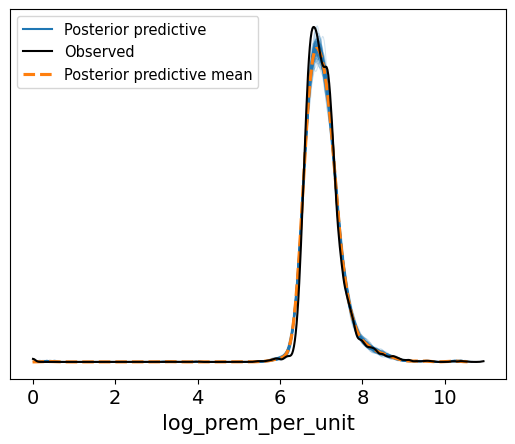

In [16]:
ppc_preds = model.predict(results, kind="response", inplace=False)

az.plot_ppc(ppc_preds, var_names=["log_prem_per_unit"], group="posterior", num_pp_samples=100)

In [17]:
print("\n" + "=" * 60)
print("Step 4: Checking convergence...")
print("=" * 60)

# Check Rhat and ESS
summary = az.summary(results, var_names=['Intercept', 'yr_scaled'] + climate_financial_vars)
print("\nFixed effects summary:")
print(summary)

# Check for convergence issues
rhat_max = summary['r_hat'].max()
ess_min = summary['ess_bulk'].min()

print(f"\nConvergence diagnostics:")
print(f"  Max R-hat: {rhat_max:.4f} {'' if rhat_max < 1.01 else ''}")
print(f"  Min ESS:   {ess_min:.0f} {'' if ess_min > 400 else ''}")

if rhat_max > 1.01:
    print("\n Warning: Some R-hat > 1.01, consider:")
    print("   - Increasing tune/draws")
    print("   - Checking for problematic parameters")


Step 4: Checking convergence...

Fixed effects summary:
                            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
Intercept                  6.954  0.033   6.889    7.013      0.001    0.001   
yr_scaled                  0.088  0.009   0.070    0.105      0.000    0.000   
flood_frequency            0.003  0.003  -0.003    0.009      0.000    0.000   
flood_property_damage      0.003  0.003  -0.003    0.009      0.000    0.000   
flood_duration_hours       0.002  0.003  -0.003    0.007      0.000    0.000   
heat_stress_index         -0.024  0.009  -0.042   -0.008      0.000    0.000   
drought_annual_mean_index -0.009  0.005  -0.019    0.001      0.000    0.000   
fire_frequency             0.018  0.011  -0.004    0.039      0.000    0.000   
fire_size                  0.006  0.003  -0.000    0.012      0.000    0.000   
unemployment_rate         -0.005  0.011  -0.025    0.015      0.000    0.000   
prop_rate                 -0.024  0.017  -0.055    0.008      0

### Forecast 2021-2023

In [19]:
# Extrapolate predictors

print("\n" + "=" * 60)
print("EXTRAPOLATING PREDICTORS")
print("=" * 60)

def extrapolate_predictors(df, vars_to_extrapolate, target_years):
    """For each zipcode, linearly extrapolate predictors to target years."""
    rows = []

    for zipcode, df_zip in df.groupby("zipcode"):
        df_zip = df_zip.sort_values("yr")
        row = {"zipcode": zipcode}

        # keep county for this zipcode
        row["county"] = df_zip["county"].iloc[0]

        years = df_zip["yr"].values

        for var in vars_to_extrapolate:
            values = df_zip[var].values

            # if too few points, fallback to last observed value
            if len(df_zip) < 2 or np.all(values == values[0]):
                for target_year in target_years:
                    row[f"{var}_{target_year}"] = values[-1]
            else:
                slope, intercept = np.polyfit(years, values, 1)
                for target_year in target_years:
                    row[f"{var}_{target_year}"] = slope * target_year + intercept

        rows.append(row)

    return pd.DataFrame(rows)

target_years = [2021, 2022, 2023]

future_predictors = extrapolate_predictors(
    final_df_bayes,
    climate_financial_vars,
    target_years
)

print(f"Extrapolated predictors for {len(future_predictors)} zipcodes")

# Predict for 2021-2023

print("\n" + "=" * 60)
print("FORECASTING 2021-2023")
print("=" * 60)

forecasts_all_years = []

for year in target_years:
    print(f"\nForecasting {year}...")

    # construct future data
    forecast_data = future_predictors[["zipcode", "county"]].copy()
    forecast_data["yr_scaled"] = year - year_min

    for var in climate_financial_vars:
        forecast_data[var] = future_predictors[f"{var}_{year}"].values

    # make sure types match training data
    forecast_data["zipcode"] = forecast_data["zipcode"].astype(str)
    forecast_data["county"] = forecast_data["county"].astype(str)

    # generate posterior predictive samples
    idata_pred = model.predict(
        results,
        data=forecast_data,
        kind="response",
        inplace=False
    )

    preds_log = idata_pred.posterior_predictive["log_prem_per_unit"]
    # dims usually: chain, draw, __obs__
    
    # inverse transform on each draw first
    preds_original = np.expm1(preds_log)

    forecast_data["predicted_mean"] = preds_original.mean(
        dim=["chain", "draw"]
    ).values

    forecast_data["predicted_lower"] = preds_original.quantile(
        0.025, dim=["chain", "draw"]
    ).values

    forecast_data["predicted_upper"] = preds_original.quantile(
        0.975, dim=["chain", "draw"]
    ).values

    forecast_data["year"] = year
    forecasts_all_years.append(forecast_data)

final_forecasts = pd.concat(forecasts_all_years, ignore_index=True)

print("\nForecasts completed!")
print(final_forecasts.head())


EXTRAPOLATING PREDICTORS
Extrapolated predictors for 1902 zipcodes

FORECASTING 2021-2023

Forecasting 2021...

Forecasting 2022...

Forecasting 2023...

Forecasts completed!
  zipcode county  yr_scaled  flood_frequency  flood_property_damage  \
0   90001  06037          3        -0.554992               -0.13883   
1   90002  06037          3        -0.554992               -0.13883   
2   90003  06037          3        -0.554992               -0.13883   
3   90004  06037          3        -0.554992               -0.13883   
4   90005  06037          3        -0.554992               -0.13883   

   flood_duration_hours  heat_stress_index  drought_annual_mean_index  \
0             -0.422891          -0.220303                   2.516706   
1             -0.422891          -0.220303                   2.516706   
2             -0.422891          -0.220303                   2.516706   
3             -0.422891          -0.220303                   2.516706   
4             -0.422891         

In [20]:
# Read data from California wildfire insurance
wildfire_insurance = pd.read_excel("../../02_processed_data/Residential-Property-Coverage-Amounts-Wildfire-Risk-and-Losses_Export.xlsx", 
sheet_name="Export_all", header=2)

# Subset data from 2021-2023, with homeowner premium insurance type
wildfire_insurance['Calendar Year'] += 2000
wildfire_insurance_21_23 = wildfire_insurance[
    (wildfire_insurance['Policy Type'] == "HO") & (wildfire_insurance['Calendar Year'].between(2021, 2023))]

# Keep the column of interest
wildfire_insurance_21_23 = wildfire_insurance_21_23[["Calendar Year", "ZIP Code", "Earned Prem", "Earned Exp"]]

In [21]:
wildfire_insurance_21_23.head()

,Calendar Year,ZIP Code,Earned Prem,Earned Exp
18,2021,90001,1629265,1976
19,2022,90001,1828773,2063
20,2023,90001,1998381,2109
60,2021,90002,2281854,2781
61,2022,90002,2583205,2922


In [22]:
# Force the zipcode to be a string
wildfire_insurance_21_23['ZIP Code'] = wildfire_insurance_21_23['ZIP Code'].astype(str)

# Keep only the largest res_ratio county for each zipcode to avoid 1 to many merge issue
crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)
crosswalk_ca_sorted_21_23 = crosswalk_ca.sort_values(by=['ZIP', 'RES_RATIO'], ascending=[True, False])
crosswalk_main_21_23 = crosswalk_ca_sorted_21_23.drop_duplicates(subset=['ZIP'], keep='first')

# Merge the wildfire_insurance file with the crosswalk
wildfire_zip_21_23 = wildfire_insurance_21_23.merge(
    crosswalk_main_21_23[['ZIP', 'COUNTY']], 
    left_on='ZIP Code', right_on='ZIP', 
    how='left'
)

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_90225/4118842553.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)


In [23]:
# Create premium per unit to show average earned premium for each housing unit
wildfire_zip_21_23 = wildfire_zip_21_23[wildfire_zip_21_23['Earned Exp'] > 0]
wildfire_zip_21_23['prem_per_unit'] = wildfire_zip_21_23['Earned Prem'] / wildfire_zip_21_23['Earned Exp']

In [24]:
wildfire_zip_21_23.head(4)

,Calendar Year,ZIP Code,Earned Prem,Earned Exp,ZIP,COUNTY,prem_per_unit
0,2021,90001,1629265,1976,90001,06037,824.526822
1,2022,90001,1828773,2063,90001,06037,886.462918
2,2023,90001,1998381,2109,90001,06037,947.549075
3,2021,90002,2281854,2781,90002,06037,820.515642


In [25]:
print("\n" + "=" * 60)
print("LOADING ACTUAL 2021-2023 DATA")
print("=" * 60)

actual_df = wildfire_zip_21_23.copy() 

actual_df = actual_df.rename(columns={
    'ZIP Code': 'zipcode', 
    'Calendar Year': 'year'
})

print(f"Actual data shape: {actual_df.shape}")
print(f"Years: {sorted(actual_df['year'].unique())}")
print(f"ZIP codes: {actual_df['zipcode'].nunique()}")

if 'prem_per_unit' not in actual_df.columns:
    print("Warning: 'prem_per_unit' column not found!")
    print(f"Available columns: {actual_df.columns.tolist()}")
else:
    print("Premium column found")


LOADING ACTUAL 2021-2023 DATA
Actual data shape: (5516, 7)
Years: [np.int64(2021), np.int64(2022), np.int64(2023)]
ZIP codes: 1874
Premium column found


In [26]:
print("\n" + "=" * 60)
print("MERGING PREDICTIONS WITH ACTUAL DATA")
print("=" * 60)

comparison_df = final_forecasts.merge(
    actual_df[['zipcode', 'year', 'prem_per_unit']],
    on=['zipcode', 'year'],
    how='inner', 
    suffixes=('_forecast', '_actual')
)

print(f"Merged data shape: {comparison_df.shape}")
print(f"ZIP codes: {comparison_df['zipcode'].nunique()}")
print(f"Years: {sorted(comparison_df['year'].unique())}")

# rename the columns
comparison_df = comparison_df.rename(columns={
    'predicted_mean': 'forecast',
    'prem_per_unit': 'actual'
})

print(comparison_df[['zipcode', 'year', 'actual', 'forecast', 'predicted_lower', 'predicted_upper']].head(10))


MERGING PREDICTIONS WITH ACTUAL DATA
Merged data shape: (5395, 18)
ZIP codes: 1819
Years: [np.int64(2021), np.int64(2022), np.int64(2023)]
  zipcode  year       actual     forecast  predicted_lower  predicted_upper
0   90001  2021   824.526822   888.302919       668.016486      1151.558274
1   90002  2021   820.515642   877.862505       664.251992      1128.943273
2   90003  2021   893.940117   953.754247       725.559295      1223.219824
3   90004  2021  3064.761194  2882.536401      2197.273920      3738.082242
4   90005  2021  4406.956376  4017.541748      3044.525179      5205.237217
5   90006  2021  1353.493220  1385.642884      1054.965282      1791.426046
6   90007  2021  1361.095890  1412.471602      1072.117213      1825.558186
7   90008  2021  1565.599561  1599.911556      1205.171712      2084.255499
8   90010  2021   954.857143  1055.891859       802.123218      1355.551169
9   90011  2021   929.964173   991.022565       745.949651      1285.420151


In [27]:
# Calculate prediction errors

print("\n" + "=" * 60)
print("CALCULATING PREDICTION ERRORS")
print("=" * 60)

comparison_df['error'] = comparison_df['forecast'] - comparison_df['actual']
comparison_df['abs_error'] = np.abs(comparison_df['error'])
comparison_df['pct_error'] = (comparison_df['error'] / comparison_df['actual']) * 100
comparison_df['abs_pct_error'] = np.abs(comparison_df['pct_error'])

comparison_df['in_ci'] = (
    (comparison_df['actual'] >= comparison_df['predicted_lower']) & 
    (comparison_df['actual'] <= comparison_df['predicted_upper'])
)

print("Error metrics calculated")


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "=" * 60)
print("OVERALL FORECAST ACCURACY (2021-2023)")
print("=" * 60)

y_actual = comparison_df['actual'].values
y_forecast = comparison_df['forecast'].values

rmse = np.sqrt(mean_squared_error(y_actual, y_forecast))
mae = mean_absolute_error(y_actual, y_forecast)
mape = comparison_df['abs_pct_error'].mean()
r2 = r2_score(y_actual, y_forecast)
coverage = comparison_df['in_ci'].mean() * 100

print(f"Sample size: {len(comparison_df)}")
print(f"\nAccuracy Metrics:")
print(f"  R²:                  {r2:.4f}")
print(f"  RMSE:                ${rmse:.2f}")
print(f"  MAE:                 ${mae:.2f}")
print(f"  MAPE:                {mape:.2f}%")
print(f"  95% CI Coverage:     {coverage:.1f}% (ideal: 95%)")

print(f"\nError Distribution:")
print(f"  Mean error:          ${comparison_df['error'].mean():.2f}")
print(f"  Median error:        ${comparison_df['error'].median():.2f}")
print(f"  Std of errors:       ${comparison_df['error'].std():.2f}")


CALCULATING PREDICTION ERRORS
Error metrics calculated

OVERALL FORECAST ACCURACY (2021-2023)
Sample size: 5395

Accuracy Metrics:
  R²:                  0.4628
  RMSE:                $2508.81
  MAE:                 $242.20
  MAPE:                14.58%
  95% CI Coverage:     95.0% (ideal: 95%)

Error Distribution:
  Mean error:          $-141.74
  Median error:        $-26.31
  Std of errors:       $2505.03


In [28]:
# Accuracy by year
print("\n" + "=" * 60)
print("ACCURACY BY YEAR")
print("=" * 60)

for year in sorted(comparison_df['year'].unique()):
    year_df = comparison_df[comparison_df['year'] == year]
    
    y_act = year_df['actual'].values
    y_for = year_df['forecast'].values
    
    r2_year = r2_score(y_act, y_for)
    rmse_year = np.sqrt(mean_squared_error(y_act, y_for))
    mape_year = year_df['abs_pct_error'].mean()
    coverage_year = year_df['in_ci'].mean() * 100
    
    print(f"\n{year} (n={len(year_df)}):")
    print(f"  R²:              {r2_year:.4f}")
    print(f"  RMSE:            ${rmse_year:.2f}")
    print(f"  MAPE:            {mape_year:.2f}%")
    print(f"  95% CI Coverage: {coverage_year:.1f}%")


ACCURACY BY YEAR

2021 (n=1814):
  R²:              0.7701
  RMSE:            $1003.77
  MAPE:            6.80%
  95% CI Coverage: 97.7%

2022 (n=1802):
  R²:              0.6589
  RMSE:            $1346.94
  MAPE:            25.82%
  95% CI Coverage: 95.0%

2023 (n=1779):
  R²:              0.3657
  RMSE:            $4027.71
  MAPE:            11.13%
  95% CI Coverage: 92.1%


### Scenario Based Forecast for 2025-2030

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("SCENARIO-BASED PREMIUM FORECASTS: 2025-2030")
print("=" * 70)

print("\n" + "=" * 70)
print("DEFINING SCENARIOS")
print("=" * 70)

# Based on Scenarios mentioned in NGFS
scenarios = {
    'Optimistic': {
        'warming': 1.5,
        'description': 'Strong climate action (Paris goals achieved)',
        'climate_growth': {
            'flood_frequency': 0.10,           # +10% by 2030
            'flood_property_damage': 0.12,
            'flood_duration_hours': 0.05,
            'heat_stress_index': 0.15,         # +15% by 2030
            'drought_annual_mean_index': 0.12,
            'fire_frequency': 0.15,            # +15% by 2030
            'fire_size': 0.12
        },
        'economic_growth': {
            'unemployment_rate': 0.0,          # Assume stable
            'prop_rate': 0.0,
            'debt_income_ratio': 0.0
        }
    },
    
    'Moderate': {
        'warming': 2.0,
        'description': 'Current policies continue',
        'climate_growth': {
            'flood_frequency': 0.25,           # +25% by 2030
            'flood_property_damage': 0.28,
            'flood_duration_hours': 0.15,
            'heat_stress_index': 0.30,         # +30% by 2030
            'drought_annual_mean_index': 0.25,
            'fire_frequency': 0.30,            # +30% by 2030
            'fire_size': 0.28
        },
        'economic_growth': {
            'unemployment_rate': 0.0,
            'prop_rate': 0.0,
            'debt_income_ratio': 0.0
        }
    },
    
    'Pessimistic': {
        'warming': 3.0,
        'description': 'Limited climate action',
        'climate_growth': {
            'flood_frequency': 0.40,           # +40% by 2030
            'flood_property_damage': 0.45,
            'flood_duration_hours': 0.25,
            'heat_stress_index': 0.50,         # +50% by 2030
            'drought_annual_mean_index': 0.45,
            'fire_frequency': 0.50,            # +50% by 2030
            'fire_size': 0.48
        },
        'economic_growth': {
            'unemployment_rate': 0.0,
            'prop_rate': 0.0,
            'debt_income_ratio': 0.0
        }
    }
}

for scenario_name, scenario in scenarios.items():
    print(f"\n{scenario_name} Scenario ({scenario['warming']}°C warming):")
    print(f"  {scenario['description']}")
    print(f"  Climate hazard growth by 2030:")
    for var, growth in scenario['climate_growth'].items():
        print(f"    {var}: +{growth*100:.0f}%")


# Calculate baseline for 2023

print("\n" + "=" * 70)
print("ESTABLISHING 2023 BASELINE")
print("=" * 70)


# Extrapolate for 2023
baseline_2023_list = []

for zipcode, df_zip in final_df_bayes[final_df_bayes['yr'] <= 2020].groupby("zipcode"):
    df_zip = df_zip.sort_values("yr")
    
    if len(df_zip) < 2:
        continue
    
    row = {"zipcode": zipcode, "county": df_zip["county"].iloc[0]}
    
    years = df_zip["yr"].values
    
    for var in climate_financial_vars:
        values = df_zip[var].values
        
        if np.all(values == values[0]):  # No variation
            row[var] = values[-1]
        else:
            slope, intercept = np.polyfit(years, values, 1)
            row[var] = slope * 2023 + intercept
    
    baseline_2023_list.append(row)

baseline_2023 = pd.DataFrame(baseline_2023_list)

print(f"2023 baseline established for {len(baseline_2023)} ZIPs")
print(f"\nBaseline statistics (2023):")
for var in climate_financial_vars[:3]: 
    print(f"  {var}: mean={baseline_2023[var].mean():.4f}, "
          f"sd={baseline_2023[var].std():.4f}")


# Predictor Values for each scenario

print("\n" + "=" * 70)
print("GENERATING SCENARIO PROJECTIONS (2025-2030)")
print("=" * 70)

target_years = [2025, 2026, 2027, 2028, 2029, 2030]

all_scenario_forecasts = {}

for scenario_name, scenario_params in scenarios.items():
    print(f"\n{'='*70}")
    print(f"SCENARIO: {scenario_name}")
    print(f"{'='*70}")
    
    scenario_forecasts = []
    
    for year in target_years:
        print(f"\n  Generating {year} projection...")
        
        year_data = baseline_2023.copy()
        year_data['year'] = year
        
        years_from_baseline = year - 2023
        
        growth_fraction = years_from_baseline / 7  # 7 years from 2023 to 2030
        
        for var, total_growth in scenario_params['climate_growth'].items():
            if var in year_data.columns:
                # baseline × (1 + growth_fraction × total_growth)
                year_data[var] = baseline_2023[var] * (1 + growth_fraction * total_growth)

        for var, total_growth in scenario_params['economic_growth'].items():
            if var in year_data.columns and total_growth != 0:
                year_data[var] = baseline_2023[var] * (1 + growth_fraction * total_growth)
        
        # Standarize the variables
        year_data_scaled = year_data.copy()
        year_data_scaled[climate_financial_vars] = scaler.transform(
            year_data[climate_financial_vars]
        )
        
        year_data_scaled['yr_scaled'] = year - year_min
        
        year_data_scaled['zipcode'] = year_data_scaled['zipcode'].astype(str)
        year_data_scaled['county'] = year_data_scaled['county'].astype(str)
        
        # Check for extreme values
        extreme_vars = []
        for var in climate_financial_vars:
            if year_data_scaled[var].abs().max() > 5:
                extreme_vars.append(var)
                # Clip
                year_data_scaled[var] = year_data_scaled[var].clip(-5, 5)
        
        if extreme_vars:
            print(f"Clipped {len(extreme_vars)} variables to [-5, 5]")
        
        
        # Generate posterior predictive samples
        idata_pred = model.predict(
            results,
            data=year_data_scaled,
            kind="response",
            inplace=False
        )
        
        preds_log = idata_pred.posterior_predictive["log_prem_per_unit"]
        
        # Transform back to original scale
        preds_original = np.expm1(preds_log)
        
        year_data['predicted_mean'] = preds_original.mean(
            dim=["chain", "draw"]
        ).values
        
        year_data['predicted_median'] = preds_original.median(
            dim=["chain", "draw"]
        ).values
        
        year_data['predicted_lower'] = preds_original.quantile(
            0.025, dim=["chain", "draw"]
        ).values
        
        year_data['predicted_upper'] = preds_original.quantile(
            0.975, dim=["chain", "draw"]
        ).values
        
        year_data['predicted_q10'] = preds_original.quantile(
            0.10, dim=["chain", "draw"]
        ).values
        
        year_data['predicted_q90'] = preds_original.quantile(
            0.90, dim=["chain", "draw"]
        ).values
        
        scenario_forecasts.append(year_data)
        
        print(f"Mean premium: ${year_data['predicted_mean'].mean():,.2f}")
        print(f"Range: ${year_data['predicted_mean'].min():,.2f} - "
              f"${year_data['predicted_mean'].max():,.2f}")
    
    # Combine all the years
    scenario_df = pd.concat(scenario_forecasts, ignore_index=True)
    all_scenario_forecasts[scenario_name] = scenario_df
    
    print(f"{scenario_name} scenario complete: "
          f"{len(scenario_df)} forecasts")


# Store the forecast summary

print("\n" + "=" * 70)
print("SAVING DETAILED FORECASTS")
print("=" * 70)

for scenario_name, scenario_df in all_scenario_forecasts.items():
    filename = f'scenario_{scenario_name.lower()}_forecasts_2025_2030.csv'
    
    output_df = scenario_df[[
        'zipcode', 'county', 'year',
        'predicted_mean', 'predicted_median',
        'predicted_lower', 'predicted_upper'
    ]].copy()
    
    output_df.to_csv(filename, index=False)
    print(f"{scenario_name}: {filename}")

SCENARIO-BASED PREMIUM FORECASTS: 2025-2030

DEFINING SCENARIOS

Optimistic Scenario (1.5°C warming):
  Strong climate action (Paris goals achieved)
  Climate hazard growth by 2030:
    flood_frequency: +10%
    flood_property_damage: +12%
    flood_duration_hours: +5%
    heat_stress_index: +15%
    drought_annual_mean_index: +12%
    fire_frequency: +15%
    fire_size: +12%

Moderate Scenario (2.0°C warming):
  Current policies continue
  Climate hazard growth by 2030:
    flood_frequency: +25%
    flood_property_damage: +28%
    flood_duration_hours: +15%
    heat_stress_index: +30%
    drought_annual_mean_index: +25%
    fire_frequency: +30%
    fire_size: +28%

Pessimistic Scenario (3.0°C warming):
  Limited climate action
  Climate hazard growth by 2030:
    flood_frequency: +40%
    flood_property_damage: +45%
    flood_duration_hours: +25%
    heat_stress_index: +50%
    drought_annual_mean_index: +45%
    fire_frequency: +50%
    fire_size: +48%

ESTABLISHING 2023 BASELINE
202